In [152]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# from src.data_loader import get_team_info
# import time



In [153]:
# ============================================================
# 1. DATA LOADING
# ============================================================
df = pd.read_csv("../data/processed/clean_matches.csv")
team_df = pd.read_csv("../data/processed/team_mapping.csv")
team_map = dict(zip(team_df.team_id, team_df.team_name))
throw_comeback_team_df = pd.read_csv("../data/processed/comeback_throw_team.csv")
picks_df = pd.read_csv("../data/raw/picks_bans_final.csv")
hero_df = pd.read_csv("../data/raw/heroes.csv")

df["radiant_team_name"] = df["radiant_team_id"].map(team_map)
df["dire_team_name"] = df["dire_team_id"].map(team_map)

print(f"Total matches loaded: {len(df)}")
df.head()

Total matches loaded: 933


,match_id,radiant_win,start_time,duration,leagueid,radiant_score,dire_score,radiant_team_id,dire_team_id,series_id,series_type,total_kills,game_speed_categorize,radiant_team_name,dire_team_name
0,8712056091,True,2026-03-01 18:10:52,47.22,19269,32,31,8291895,9467224,1069888.0,2.0,63,Late,Tundra Esports,Aurora Gaming
1,8711970053,True,2026-03-01 17:07:03,31.98,19269,37,8,9467224,8291895,1069888.0,2.0,45,Normal,Aurora Gaming,Tundra Esports
2,8711885801,False,2026-03-01 16:08:54,28.18,19269,6,28,9467224,8291895,1069888.0,2.0,34,Fast,Aurora Gaming,Tundra Esports
3,8711768658,False,2026-03-01 14:54:59,41.80,19269,11,37,9467224,8291895,1069888.0,2.0,48,Late,Aurora Gaming,Tundra Esports
4,8711578057,True,2026-03-01 13:05:55,34.67,19269,30,15,9467224,2163,1069815.0,1.0,45,Normal,Aurora Gaming,Team Liquid


In [154]:
# ============================================================
# 2. DATA OVERVIEW
# ============================================================

df.info()
print("\n--- Descriptive Statistics ---")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 933 entries, 0 to 932
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   match_id               933 non-null    int64  
 1   radiant_win            933 non-null    bool   
 2   start_time             933 non-null    object 
 3   duration               933 non-null    float64
 4   leagueid               933 non-null    int64  
 5   radiant_score          933 non-null    int64  
 6   dire_score             933 non-null    int64  
 7   radiant_team_id        933 non-null    int64  
 8   dire_team_id           933 non-null    int64  
 9   series_id              931 non-null    float64
 10  series_type            931 non-null    float64
 11  total_kills            933 non-null    int64  
 12  game_speed_categorize  933 non-null    object 
 13  radiant_team_name      933 non-null    object 
 14  dire_team_name         933 non-null    object 
dtypes: boo

,match_id,duration,leagueid,radiant_score,dire_score,radiant_team_id,dire_team_id,series_id,series_type,total_kills
count,9.330000e+02,933.000000,933.000000,933.000000,933.000000,9.330000e+02,9.330000e+02,9.310000e+02,931.000000,933.000000
mean,8.606859e+09,39.987610,18713.996785,23.457663,23.869239,7.658651e+06,7.382320e+06,1.046058e+06,1.092374,47.326902
std,6.551143e+07,10.775239,668.500971,10.806212,11.127241,3.186902e+06,3.406140e+06,1.490195e+04,0.863885,12.858144
min,8.510884e+09,15.750000,17419.000000,1.000000,1.000000,3.600000e+01,3.600000e+01,1.022755e+06,0.000000,14.000000
25%,8.560169e+09,32.500000,18863.000000,15.000000,14.000000,8.254145e+06,7.119388e+06,1.035897e+06,1.000000,39.000000
50%,8.600165e+09,38.350000,18988.000000,24.000000,24.000000,9.303484e+06,9.247354e+06,1.045547e+06,1.000000,46.000000
75%,8.678990e+09,45.800000,19099.000000,32.000000,32.000000,9.572001e+06,9.467224e+06,1.061831e+06,1.000000,55.000000
max,8.712056e+09,85.120000,19269.000000,53.000000,61.000000,9.989747e+06,9.989756e+06,1.069888e+06,3.000000,95.000000


In [155]:
# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

bins = [0, 25, 35, 45, 60, 100]
labels = ["Very Fast", "Fast", "Normal", "Late", "Very Late"]

df["duration_group"] = pd.cut(df["duration"], bins=bins, labels=labels)
df["duration_group"].value_counts().sort_index()

duration_group
Very Fast     41
Fast         288
Normal       354
Late         199
Very Late     51
Name: count, dtype: int64

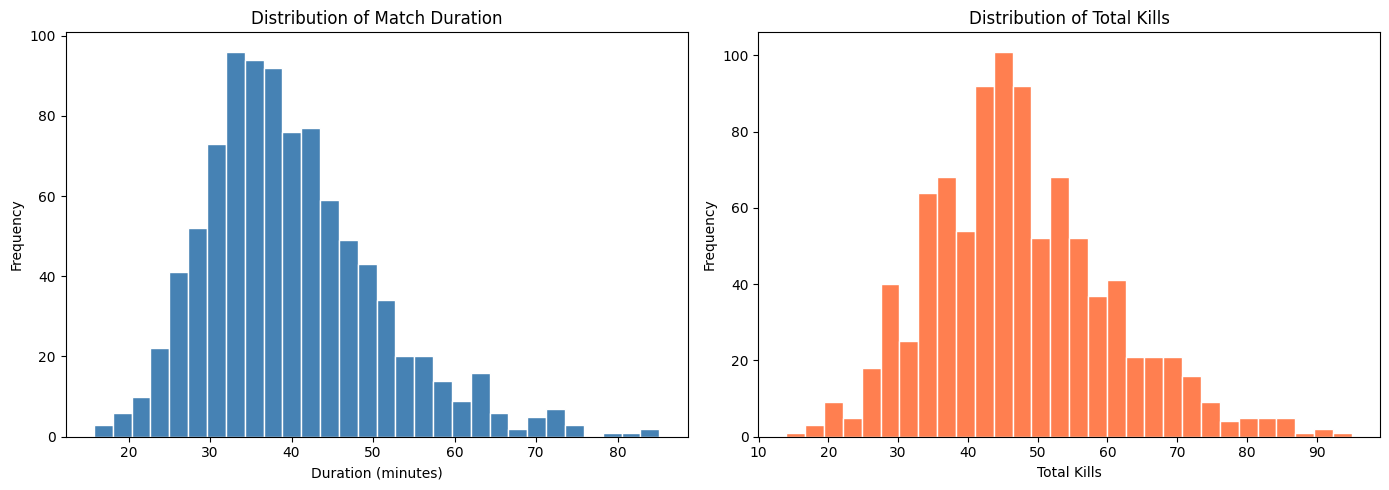

In [156]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of match duration
axes[0].hist(df["duration"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Match Duration")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Frequency")

# Distribution of total kills
axes[1].hist(df["total_kills"], bins=30, color="coral", edgecolor="white")
axes[1].set_title("Distribution of Total Kills")
axes[1].set_xlabel("Total Kills")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

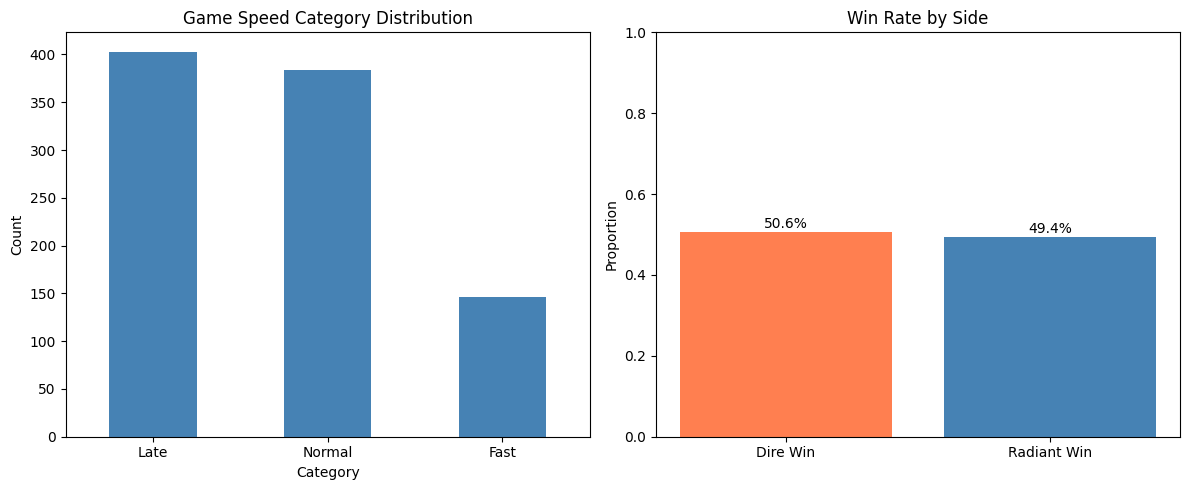


Radiant win rate:
radiant_win
False    0.505895
True     0.494105
Name: proportion, dtype: float64


In [157]:
# Game speed category distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["game_speed_categorize"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Game Speed Category Distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(rotation=0)

# Radiant win rate
win_counts = df["radiant_win"].value_counts(normalize=True)
axes[1].bar(["Dire Win", "Radiant Win"], win_counts.values, color=["coral", "steelblue"])
axes[1].set_title("Win Rate by Side")
axes[1].set_ylabel("Proportion")

axes[1].set_ylim(0, 1)
for i, v in enumerate(win_counts.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center")

plt.tight_layout()
plt.show()

print("\nRadiant win rate:")
print(df["radiant_win"].value_counts(normalize=True))

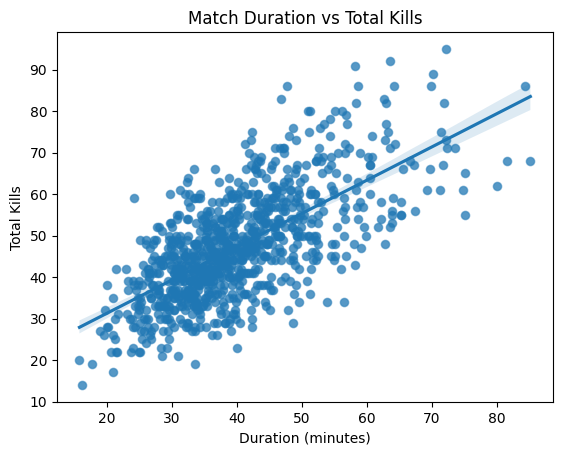


Korelasi durasi vs total kills: 0.672


In [158]:
# correlation duration vs total kills
sns.scatterplot(data=df, x="duration", y="total_kills", alpha=0.5)
sns.regplot(data=df, x="duration", y="total_kills", scatter_kws={"alpha":0.5})
plt.title("Match Duration vs Total Kills")
plt.xlabel("Duration (minutes)")
plt.ylabel("Total Kills")
plt.show()

print(f"\nKorelasi durasi vs total kills: {df['duration'].corr(df['total_kills']):.3f}")

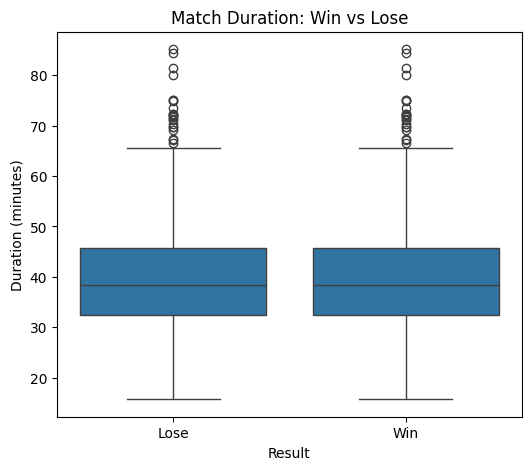

In [159]:
plt.figure(figsize=(6,5))
sns.boxplot(data=teams_result, x="win", y="duration")

plt.xticks([0,1], ["Lose", "Win"])
plt.title("Match Duration: Win vs Lose")
plt.xlabel("Result")
plt.ylabel("Duration (minutes)")

plt.show()

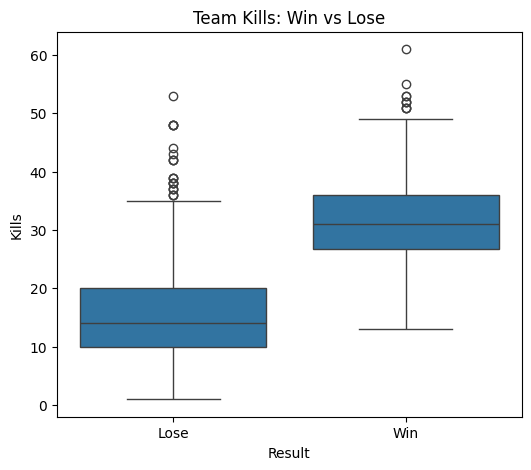

In [160]:
plt.figure(figsize=(6,5))
sns.boxplot(data=teams_result, x="win", y="kills")

plt.xticks([0,1], ["Lose", "Win"])
plt.title("Team Kills: Win vs Lose")
plt.xlabel("Result")
plt.ylabel("Kills")

plt.show()

In [161]:
# ============================================================
# 5. TEAM ANALYSIS
# ============================================================


radiant = df[["match_id", "radiant_team_name", "radiant_win", 
        "duration", "radiant_score", "total_kills"]].copy()
radiant.columns = ["match_id", "team_name", "win", "duration", "kills", "total_kills"]

dire = df[["match_id", "dire_team_name", "radiant_win", 
        "duration", "dire_score", "total_kills"]].copy()
dire.columns = ["match_id", "team_name", "radiant_win", "duration", "kills", "total_kills"]
dire["win"] = ~dire["radiant_win"]
dire = dire[["match_id", "team_name", "win", "duration", "kills", "total_kills"]]

teams_result = pd.concat([radiant, dire], ignore_index=True)

# Exclude tim yang data-nya tidak lengkap / bukan tim resmi
EXCLUDED_TEAMS = ["Team Somnus", "Team Quinn"]
teams_result = teams_result[~teams_result["team_name"].isin(EXCLUDED_TEAMS)]

print(f"Total team-match records: {len(teams_result)}")
print(f"Unique teams: {teams_result['team_name'].nunique()}")

Total team-match records: 1864
Unique teams: 32


In [162]:
# Hitung statistik per tim
wins_only = teams_result[teams_result["win"] == True]
losses_only = teams_result[teams_result["win"] == False]

# Agregasi utama
team_stats = teams_result.groupby("team_name").agg(
    total_wins=("win", "sum"),
    total_matches=("win", "count"),
    avg_duration=("duration", "mean"),
    avg_kills=("total_kills", "mean")
).reset_index()

# Rata-rata durasi & kills saat menang vs kalah
avg_win_dur  = wins_only.groupby("team_name")["duration"].mean().rename("avg_win_duration")
avg_lose_dur = losses_only.groupby("team_name")["duration"].mean().rename("avg_lose_duration")
avg_win_kills  = wins_only.groupby("team_name")["kills"].mean().rename("avg_kills_win")
avg_lose_kills = losses_only.groupby("team_name")["kills"].mean().rename("avg_kills_lose")

# Gabungkan semua
team_stats = (team_stats
    .join(avg_win_dur, on="team_name")
    .join(avg_lose_dur, on="team_name")
    .join(avg_win_kills, on="team_name")
    .join(avg_lose_kills, on="team_name")
)
team_stats["winrate"] = team_stats["total_wins"] / team_stats["total_matches"]

print("Top 10 teams by win rate (min 20 matches):")
(team_stats[team_stats["total_matches"] >= 20]
    .sort_values("winrate", ascending=False)
    .head(10))

Top 10 teams by win rate (min 20 matches):


,team_name,total_wins,total_matches,avg_duration,avg_kills,avg_win_duration,avg_lose_duration,avg_kills_win,avg_kills_lose,winrate
26,Tundra Esports,92,140,40.091857,49.414286,38.695000,42.769167,32.119565,17.208333,0.657143
19,Team Falcons,76,123,41.621951,47.991870,41.356316,42.051489,31.184211,17.425532,0.617886
20,Team Liquid,82,134,39.899627,49.955224,38.585488,41.971923,32.463415,18.346154,0.611940
22,Team Spirit,62,107,40.273738,47.130841,38.488871,42.732889,31.854839,16.888889,0.579439
11,PARIVISION,49,87,42.245632,46.000000,40.111429,44.997632,30.000000,16.736842,0.563218
2,Aurora Gaming,48,88,40.815909,47.136364,42.336042,38.991750,32.145833,14.925000,0.545455
24,Team Yandex,57,105,40.139524,47.866667,38.868596,41.648750,31.982456,16.625000,0.542857
7,MOUZ,79,146,37.005068,47.513699,35.960506,38.236716,29.797468,15.507463,0.541096
10,OG,45,84,40.431548,45.666667,38.762667,42.357179,32.555556,15.102564,0.535714
8,Natus Vincere,45,89,41.966742,48.269663,42.048889,41.882727,28.933333,16.181818,0.505618


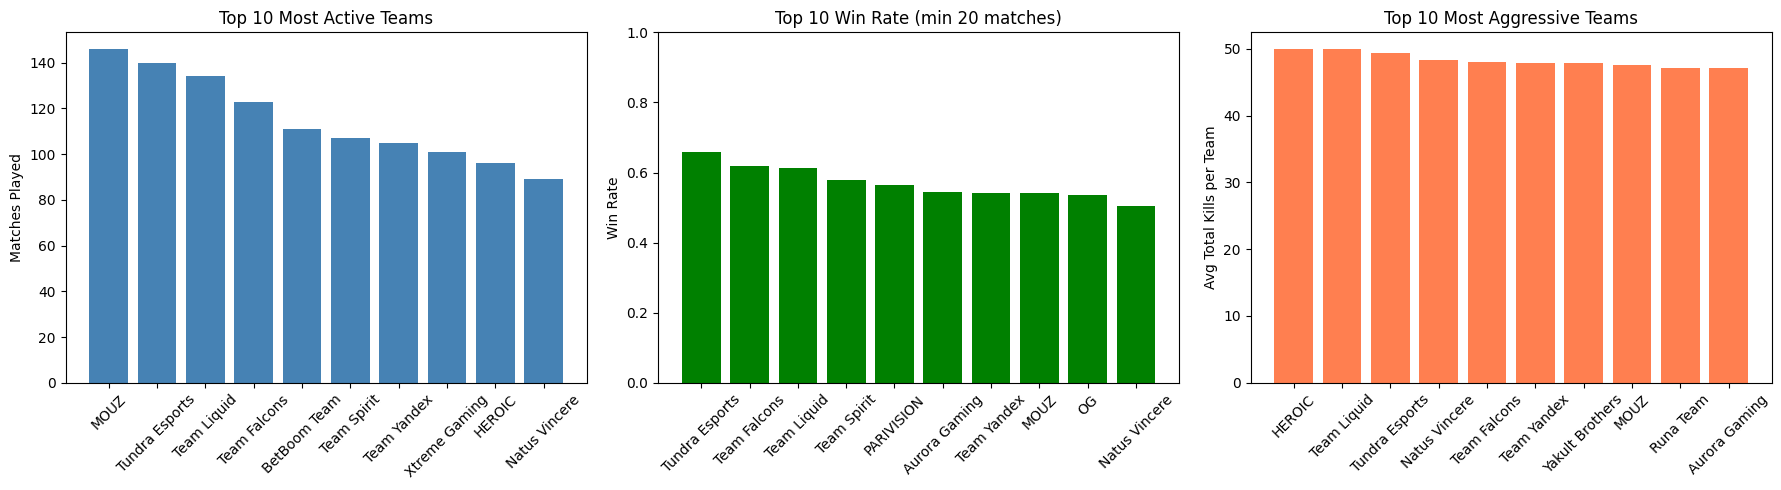

In [163]:
# ============================================================
# 6. VISUALIZATIONS: TEAM RANKINGS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 10 most active teams
top_active = (team_stats
    .sort_values("total_matches", ascending=False)
    .head(10))
axes[0].bar(top_active["team_name"], top_active["total_matches"], color="steelblue")
axes[0].set_title("Top 10 Most Active Teams")
axes[0].set_ylabel("Matches Played")
axes[0].tick_params(axis="x", rotation=45)

# Top 10 by win rate (min 20 matches)
top_winrate = (team_stats[team_stats["total_matches"] >= 20]
    .sort_values("winrate", ascending=False)
    .head(10))
axes[1].bar(top_winrate["team_name"], top_winrate["winrate"], color="green")
axes[1].set_title("Top 10 Win Rate (min 20 matches)")
axes[1].set_ylabel("Win Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

# Top 10 most aggressive teams (avg kills per game)
top_kills = (team_stats[team_stats["total_matches"] >= 20]
            .sort_values("avg_kills", ascending=False)
            .head(10))
axes[2].bar(top_kills["team_name"], top_kills["avg_kills"], color="coral")
axes[2].set_title("Top 10 Most Aggressive Teams")
axes[2].set_ylabel("Avg Total Kills per Team")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [164]:
# ============================================================
# 7. THROW & COMEBACK ANALYSIS
# ============================================================

# throw   : nilai net worth advantage saat tim yg unggul akhirnya kalah
# comeback: nilai net worth disadvantage saat tim yg tertinggal berhasil menang
# Overview

throw_matches    = throw_comeback_team_df[throw_comeback_team_df["throw"] > 3000]
comeback_matches = throw_comeback_team_df[throw_comeback_team_df["comeback"] > 3000]
normal_matches = throw_comeback_team_df[
    (throw_comeback_team_df["throw"].fillna(0) <= 3000) & 
    (throw_comeback_team_df["comeback"].fillna(0) <= 3000)
]
print(f"Total matches dengan throw   : {len(throw_matches)} ({len(throw_matches)/len(throw_comeback_team_df):.1%})")
print(f"Total matches dengan comeback: {len(comeback_matches)} ({len(comeback_matches)/len(throw_comeback_team_df):.1%})")
print(f"Total matches dengan normal: {len(normal_matches)} ({len(normal_matches)/len(throw_comeback_team_df):.1%})")

Total matches dengan throw   : 116 (12.4%)
Total matches dengan comeback: 113 (12.1%)
Total matches dengan normal: 704 (75.5%)


In [165]:
# Distribution per team
throw_counts = throw_matches["throw_team"].value_counts().reset_index()
throw_counts.columns = ["team_name", "throw_count"]

throw_counts = throw_counts.merge(
    team_stats[["team_name","total_matches"]], on="team_name", how="left"
    )

throw_counts["throw_rate"] = throw_counts["throw_count"] / throw_counts["total_matches"]

comeback_counts = comeback_matches["comeback_team"].value_counts().reset_index()
comeback_counts.columns = ["team_name", "comeback_count"]

comeback_counts = comeback_counts.merge(
    team_stats[["team_name", "total_matches"]], on="team_name", how="left"
    )

comeback_counts["comeback_rate"] = comeback_counts["comeback_count"] / comeback_counts["total_matches"]

In [166]:
#throw rate
throw_counts.sort_values("throw_rate", ascending=False, ignore_index=True).head(10)

,team_name,throw_count,total_matches,throw_rate
0,Team Tidebound,5,35,0.142857
1,Team Cobra,2,16,0.125000
2,Runa Team,3,24,0.125000
3,Team Falcons,14,123,0.113821
4,Yakult Brothers,8,78,0.102564
5,Nigma Galaxy,3,34,0.088235
6,Vici Gaming,1,12,0.083333
7,PARIVISION,7,87,0.080460
8,Natus Vincere,7,89,0.078652
9,Tundra Esports,11,140,0.078571


In [167]:
# comeback rate
comeback_counts.sort_values("comeback_rate", ascending=False, ignore_index=True).head(10)

,team_name,comeback_count,total_matches,comeback_rate
0,Natus Vincere,17,89,0.191011
1,Team Nemesis,2,16,0.125000
2,Team Spirit,11,107,0.102804
3,Team Falcons,12,123,0.097561
4,Aurora Gaming,8,88,0.090909
5,Nigma Galaxy,3,34,0.088235
6,Vici Gaming,1,12,0.083333
7,Tundra Esports,11,140,0.078571
8,paiN Gaming,1,13,0.076923
9,Pipsqueak+4,1,14,0.071429


In [168]:
# proporsi

speed_df = pd.DataFrame({
    "overall": throw_comeback_team_df["game_speed_categorize"].value_counts(normalize=True),
    "throw": throw_matches["game_speed_categorize"].value_counts(normalize=True),
    "comeback": comeback_matches["game_speed_categorize"].value_counts(normalize=True)
})

speed_df

,overall,throw,comeback
game_speed_categorize,,,
Late,0.431940,0.784483,0.769912
Normal,0.411576,0.198276,0.221239
Fast,0.156484,0.017241,0.008850


In [169]:
mental = comeback_counts.merge(
    throw_counts[["team_name", "throw_rate"]], on="team_name", how="left"
)

mental["mental_score"] = mental["comeback_rate"] - mental["throw_rate"]

mental.sort_values("mental_score", ascending=False).head(10)

,team_name,comeback_count,total_matches,comeback_rate,throw_rate,mental_score
0,Natus Vincere,17,89,0.191011,0.078652,0.112360
15,Team Nemesis,2,16,0.125000,0.062500,0.062500
2,Team Spirit,11,107,0.102804,0.046729,0.056075
7,Xtreme Gaming,6,101,0.059406,0.019802,0.039604
4,Aurora Gaming,8,88,0.090909,0.068182,0.022727
6,MOUZ,7,146,0.047945,0.027397,0.020548
5,Team Liquid,8,134,0.059701,0.044776,0.014925
13,Nigma Galaxy,3,34,0.088235,0.088235,0.000000
20,paiN Gaming,1,13,0.076923,0.076923,0.000000
16,Pipsqueak+4,1,14,0.071429,0.071429,0.000000


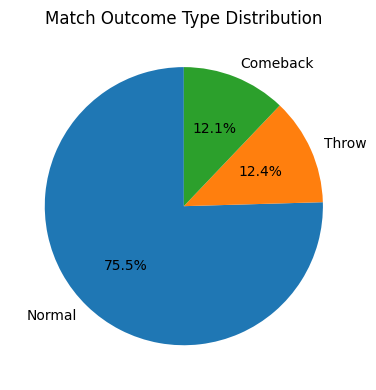

In [170]:
# ============================================================
# 8. VISUALIZATIONS: COMEBACK & THROW
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4))

ax.pie(
    [len(normal_matches), len(throw_matches), len(comeback_matches)],
    labels=["Normal", "Throw", "Comeback"],
    autopct="%1.1f%%",
    startangle=90
)
ax.set_title("Match Outcome Type Distribution")
plt.tight_layout()
plt.show()

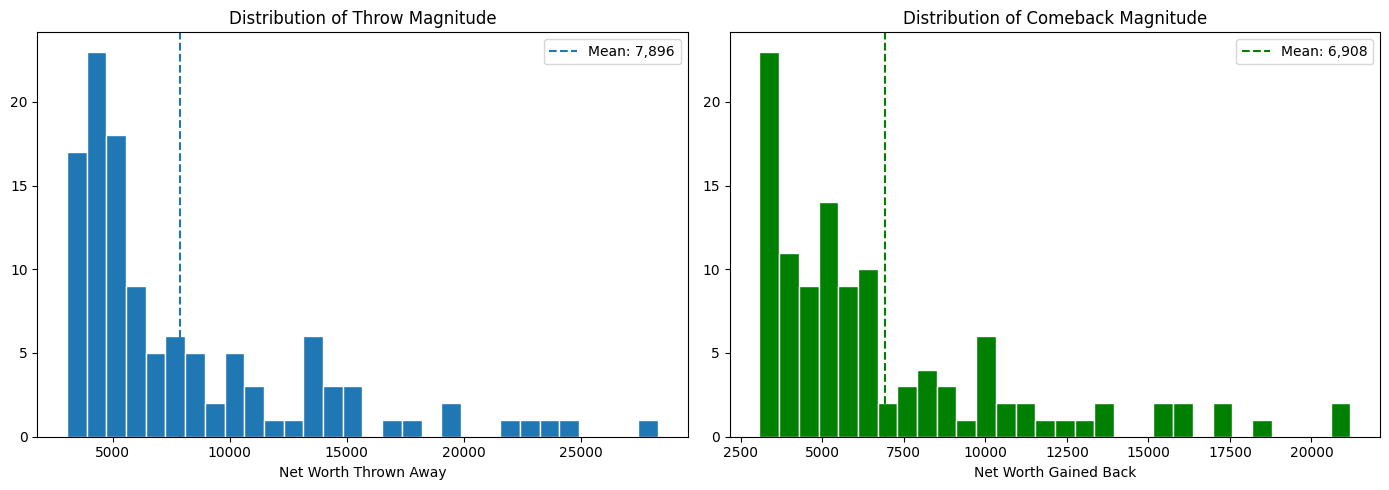

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram throw
axes[0].hist(throw_matches["throw"], bins=30, edgecolor="white")
axes[0].axvline(throw_matches["throw"].mean(), linestyle="--", label=f'Mean: {throw_matches["throw"].mean():,.0f}')
axes[0].set_title("Distribution of Throw Magnitude")
axes[0].set_xlabel("Net Worth Thrown Away")
axes[0].legend()

# Histogram comeback — coba lengkapi sendiri!
axes[1].hist(comeback_matches["comeback"], bins=30, edgecolor="white", color="green")
axes[1].axvline(comeback_matches["comeback"].mean(), linestyle="--", color="green", label=f'Mean: {comeback_matches["comeback"].mean():,.0f}')
axes[1].set_title("Distribution of Comeback Magnitude")
axes[1].set_xlabel("Net Worth Gained Back")
axes[1].legend()

plt.tight_layout()
plt.show()

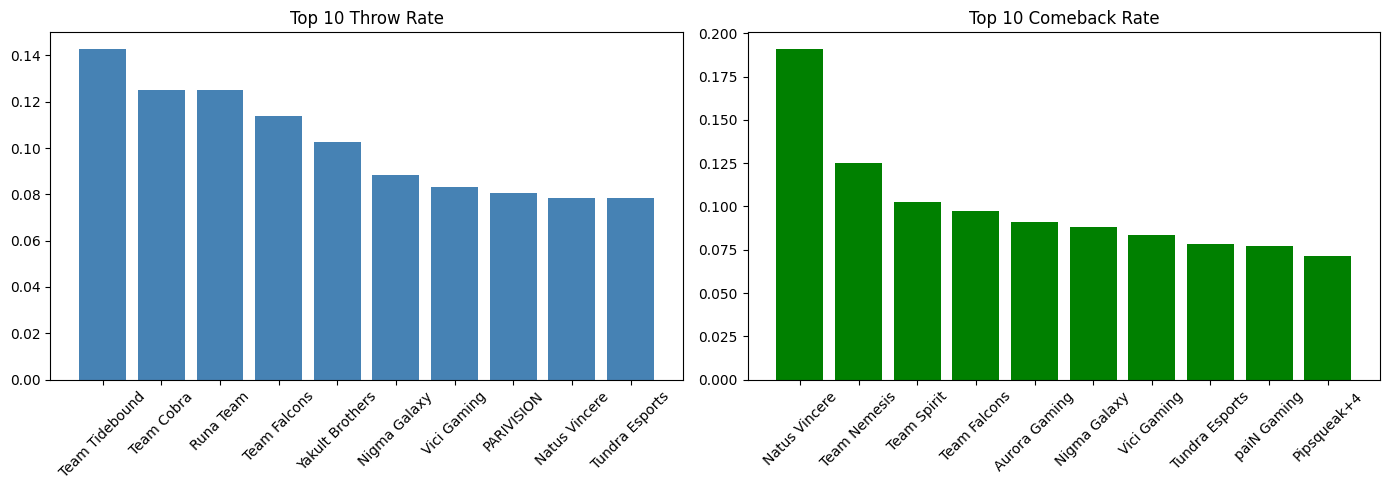

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#top 10 throw

top_throw = (throw_counts
    .sort_values("throw_rate", ascending=False)
    .head(10))
axes[0].bar(top_throw["team_name"], top_throw["throw_rate"], color="steelblue")
axes[0].set_title("Top 10 Throw Rate")
axes[0].tick_params(axis="x", rotation=45)

top_comeback = (comeback_counts
    .sort_values("comeback_rate", ascending=False)
    .head(10))
axes[1].bar(top_comeback["team_name"], top_comeback["comeback_rate"], color="green")
axes[1].set_title("Top 10 Comeback Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

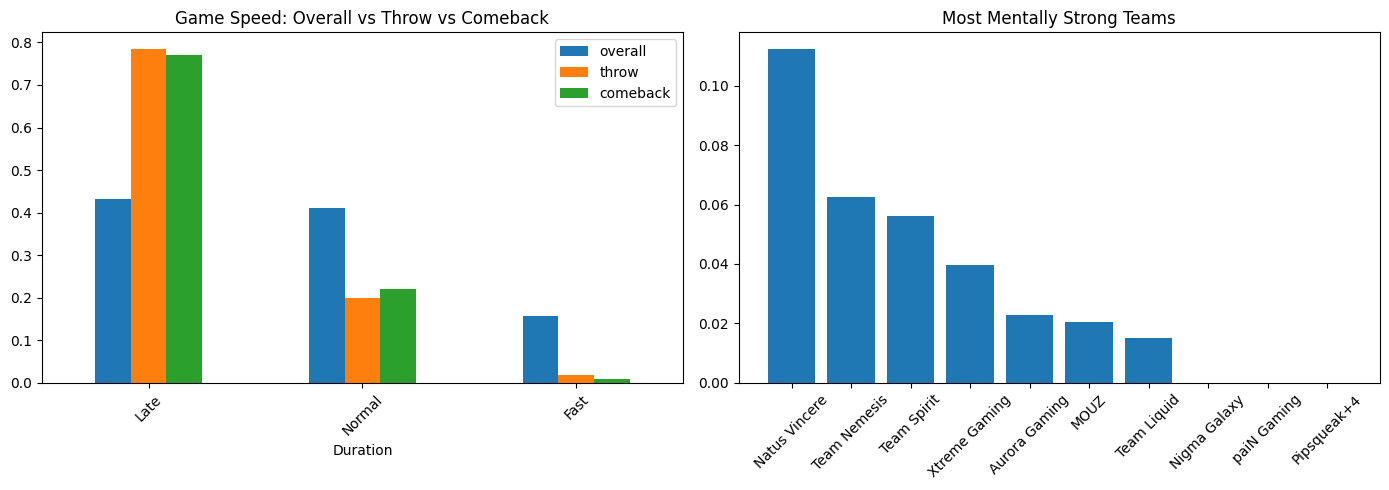

In [173]:
# viz game speed & mental baja

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
speed_df.plot(kind="bar", ax=axes[0])
axes[0].set_title("Game Speed: Overall vs Throw vs Comeback")
axes[0].set_xlabel("Duration")
axes[0].tick_params(axis="x", rotation=45)

top_mental = mental.sort_values("mental_score", ascending=False).head(10)

axes[1].bar(top_mental["team_name"], top_mental["mental_score"])
axes[1].set_title("Most Mentally Strong Teams")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [174]:
# # Scatter plot: Throw vs Comeback

fig = px.scatter(
    mental,
    x="throw_rate",
    y="comeback_rate",
    hover_name="team_name",
    size="total_matches",
    title="Team Mentality Map (Throw vs Comeback)"
)
fig.add_hline(y=mental["comeback_rate"].mean(), line_dash="dash")
fig.add_vline(x=mental["throw_rate"].mean(), line_dash="dash")
fig.show()       


In [175]:
# ============================================================
# 9. TEAM HERO PICKS ANALYSIS
# ============================================================
#mapping team_id to team_name
picks_df["radiant_team_name"] = picks_df["radiant_team_id"].map(team_map)
picks_df["dire_team_name"] = picks_df["dire_team_id"].map(team_map)

#assign team_name based on side
picks_df["team_name"] = picks_df["radiant_team_name"]
picks_df.loc[picks_df["team"] == "dire", "team_name"] = picks_df["dire_team_name"]

#create win col
picks_df["win"] = (
    (picks_df["team"] == "radiant") & (picks_df["radiant_win"] == True)
) | (
    (picks_df["team"] == "dire") & (picks_df["radiant_win"] == False)
)

#preview
picks_df[["team", "team_name", "hero_id", "win"]].head()

,team,team_name,hero_id,win
0,dire,Aurora Gaming,110,False
1,radiant,Tundra Esports,64,True
2,radiant,Tundra Esports,78,True
3,dire,Aurora Gaming,102,False
4,dire,Aurora Gaming,27,False


In [176]:
#mapping hero_id to hero_name

picks_df = picks_df.merge(hero_df, on="hero_id", how="left")
picks_df[["team_name", "hero_name", "primary_attr", "win"]].head()

,team_name,hero_name,primary_attr,win
0,Aurora Gaming,Phoenix,str,False
1,Tundra Esports,Jakiro,int,True
2,Tundra Esports,Brewmaster,all,True
3,Aurora Gaming,Abaddon,all,False
4,Aurora Gaming,Shadow Shaman,int,False


In [177]:
#most picked heroes overall

picks_df["hero_name"].value_counts().head(10)


hero_name
Jakiro               361
Tusk                 292
Dragon Knight        259
Mars                 248
Centaur Warrunner    244
Shadow Demon         243
Hoodwink             236
Warlock              218
Gyrocopter           199
Puck                 183
Name: count, dtype: int64

In [178]:
#hero winrate overall

hero_winrate = picks_df.groupby("hero_name").agg(
    picks= ("win", "count"),
    win= ("win", "sum"),
    win_rate= ("win", "mean")
).reset_index()

#filter min 5 picks
hero_winrate = hero_winrate[hero_winrate["picks"] >= 5]
hero_winrate.sort_values("win_rate", ascending=False).head(10)

,hero_name,picks,win,win_rate
118,Winter Wyvern,6,6,1.000000
26,Drow Ranger,5,4,0.800000
46,Legion Commander,5,4,0.800000
33,Faceless Void,23,16,0.695652
105,Treant Protector,27,18,0.666667
58,Medusa,31,20,0.645161
27,Earth Spirit,25,16,0.640000
59,Meepo,11,7,0.636364
51,Lion,35,22,0.628571
38,Invoker,78,49,0.628205


In [179]:
# Most picked heroes per tim
hero_per_team = picks_df.groupby(["team_name", "hero_name"]).agg(
    picks=("win", "count")
).reset_index()

#top 5 hero per team
hero_per_team.sort_values(["team_name" ,"picks"], ascending=[True, False]).groupby("team_name").head(5)

,team_name,hero_name,picks
17,1w Team,Mars,5
10,1w Team,Hoodwink,4
1,1w Team,Axe,3
7,1w Team,Dragon Knight,3
18,1w Team,Naga Siren,3
...,...,...,...
1893,paiN Gaming,Jakiro,4
1905,paiN Gaming,Razor,4
1889,paiN Gaming,Clockwerk,3
1891,paiN Gaming,Ember Spirit,3


In [180]:
#hero winrate per team
hero_winrate_per_team = picks_df.groupby(["team_name", "hero_name"]).agg(
    picks= ("win", "count"),
    win_rate= ("win", "mean")
).reset_index()

hero_winrate_per_team = hero_winrate_per_team[hero_winrate_per_team["picks"] >= 3]

In [181]:
#primary attr distribution

attr_stats = picks_df.groupby("primary_attr").agg(
    picks= ("win", "count"),
    win_rate= ("win", "mean")
).reset_index()

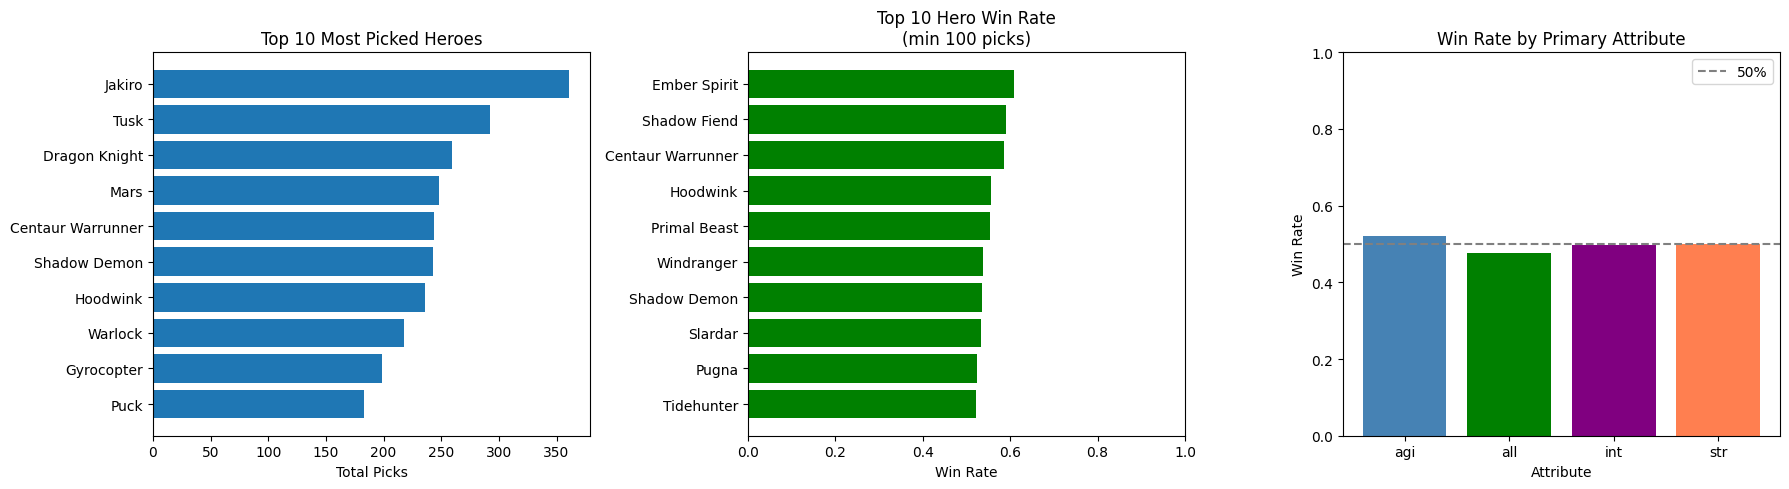

In [188]:
# ============================================================
# Visualisasi
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Top 10 most picked heroes overall
top_picked = picks_df["hero_name"].value_counts().head(10)
axes[0].barh(top_picked.index[::-1], top_picked.values[::-1])
axes[0].set_title("Top 10 Most Picked Heroes")
axes[0].set_xlabel("Total Picks")

# 2. Top 10 hero win rate overall (min 10 picks)
top_winrate = (hero_winrate[hero_winrate["picks"] >= 100]
    .sort_values("win_rate", ascending=False)
    .head(10))
axes[1].barh(top_winrate["hero_name"][::-1], top_winrate["win_rate"][::-1], color="green")
axes[1].set_title("Top 10 Hero Win Rate\n(min 100 picks)")
axes[1].set_xlabel("Win Rate")
axes[1].set_xlim(0, 1)

# 3. Primary attr win rate
colors = {"agi": "steelblue", "str": "coral", "int": "purple", "all": "green"}
bar_colors = [colors.get(a, "gray") for a in attr_stats["primary_attr"]]
axes[2].bar(attr_stats["primary_attr"], attr_stats["win_rate"], color=bar_colors)
axes[2].set_title("Win Rate by Primary Attribute")
axes[2].set_xlabel("Attribute")
axes[2].set_ylabel("Win Rate")
axes[2].set_ylim(0, 1)
axes[2].axhline(0.5, linestyle="--", color="gray", label="50%")
axes[2].legend()

plt.tight_layout()
plt.show()


In [184]:
fig = px.scatter(
    hero_scatter,
    x="picks",
    y="win_rate",
    hover_name="hero_name",
    size="picks",
    title="Hero Pick Count vs Win Rate"
)
fig.add_hline(y=hero_scatter["win_rate"].mean(), line_dash="dash", line_color="gray")
fig.show()